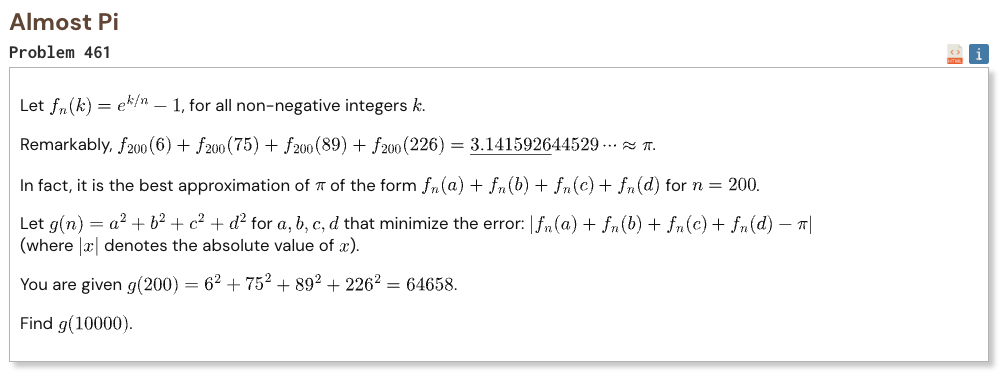

## Initial approach

-   split the four terms into two pairs and search for two pair sums whose total is closest to pi
-   only generate pair sums that could belong to a solution already known to be within a small error around pi
-   use monotonic bounds to discard most impossible pairs before storing them
-   sort the two remaining pair-sum collections and find the closest combination efficiently
-   recover the original four indices from the two best pair sums and add their squares
-   use numpy to generate and search the large pair-sum arrays efficiently without creating hundreds of millions of Python objects

In [1]:
%%time

import math
from array import array
import numpy as np

n = 10_000
delta = 1e-3
target = math.pi

limit = math.ceil(
    n * math.log(target + delta + 1)
)

values = np.expm1(
    np.arange(limit + 1, dtype=np.float64) / n
)

lower = target - delta
upper = target + delta

small_buffer = array("d")
large_buffer = array("d")

for a in range(limit + 1):
    fa = values[a]

    if 4 * fa > upper:
        break

    max_fb = (upper - fa) / 3

    bmax = (
        np.searchsorted(
            values,
            max_fb,
            side="right"
        )
        - 1
    )

    bmax = min(bmax, limit)

    if bmax >= a:
        row = fa + values[a:bmax + 1]
        small_buffer.frombytes(
            np.asarray(
                row,
                dtype=np.float64
            ).tobytes()
        )

for d in range(limit, -1, -1):
    fd = values[d]

    if 4 * fd < lower:
        break

    min_fc = max(
        0.0,
        (lower - fd) / 3
    )

    max_fc = upper - fd

    cmin = np.searchsorted(
        values,
        min_fc,
        side="left"
    )

    cmax = (
        np.searchsorted(
            values,
            max_fc,
            side="right"
        )
        - 1
    )

    cmax = min(cmax, d)

    if cmin <= cmax:
        row = values[cmin:cmax + 1] + fd
        large_buffer.frombytes(
            np.asarray(
                row,
                dtype=np.float64
            ).tobytes()
        )

small = np.frombuffer(
    small_buffer,
    dtype=np.float64
)

large = np.frombuffer(
    large_buffer,
    dtype=np.float64
)

small.sort()
large.sort()

best_error = float("inf")
best_small = 0.0
best_large = 0.0

chunk_size = 1_000_000
large_size = len(large)

for start in range(0, len(small), chunk_size):
    x = small[start:start + chunk_size]

    wanted = target - x

    pos = np.searchsorted(
        large,
        wanted
    )

    minimum = np.searchsorted(
        large,
        x
    )

    idx = np.maximum(
        pos,
        minimum
    )

    valid = idx < large_size

    if np.any(valid):
        xv = x[valid]
        iv = idx[valid]

        yv = large[iv]

        errors = np.abs(
            xv + yv - target
        )

        local = np.argmin(errors)

        if errors[local] < best_error:
            best_error = errors[local]
            best_small = xv[local]
            best_large = yv[local]

    idx = np.maximum(
        pos,
        minimum
    ) - 1

    valid = idx >= minimum

    if np.any(valid):
        xv = x[valid]
        iv = idx[valid]

        yv = large[iv]

        errors = np.abs(
            xv + yv - target
        )

        local = np.argmin(errors)

        if errors[local] < best_error:
            best_error = errors[local]
            best_small = xv[local]
            best_large = yv[local]

def recover_pair(pair_target):
    i = 0
    j = limit

    best_i = 0
    best_j = 0
    best = float("inf")

    while i <= j:
        total = values[i] + values[j]
        error = abs(total - pair_target)

        if error < best:
            best = error
            best_i = i
            best_j = j

        if total < pair_target:
            i += 1
        else:
            j -= 1

    return best_i, best_j

a, b = recover_pair(best_small)
c, d = recover_pair(best_large)

result = (
    a * a
    + b * b
    + c * c
    + d * d
)

print("Result:", result)

Result: 159820276
CPU times: user 3.5 s, sys: 202 ms, total: 3.7 s
Wall time: 3.88 s
